 AIM: Navigate through the maze to reach a goal while interacting with different objects (such as walls, keys, and doors) and avoiding an enemy.


**Agent:** The "player" (represented by player_pos).

**Environment:** The maze is the environment where the agent interacts.

**State:** The state in the simulation is represented by the player's position and the state of the environment (ex. where the walls, doors, and keys are located).

**Actions:** The player can take four actions: UP, DOWN, LEFT, and RIGHT. These actions change the player's position in the environment.

**Rewards:** The player receives rewards based on the state they reach:

  * Goal: +1 reward.
  * Wall: -0.05 penalty.
  * Step: -0.001 penalty.
  * Caught by enemy: -1 penalty.
  * Collecting key or opening door.

### Task: 1 To create the environment and identify the actions and rewards.

In [ ]:
import random

maze = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1, 2, 0, 1],    #  0= Open Space, 1= Wall, 2= Goal, 3 = Door, 4= Key
    [1, 0, 1, 0, 1, 1, 3, 1],
    [1, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 1],
    [1, 0, 1, 4, 1, 0, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1]
]

TILE_SIZE = 64
tiles = ['empty', 'wall', 'goal', 'door', 'key']
player_pos = [1, 1]  
enemy_pos = [3, 6] 
enemy_yv = -1
unlock = 0

actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']

def get_tile(pos):
    row, col = pos
    return tiles[maze[row][col]]

def move_player(action, pos):
    row, col = pos
    if action == 'UP':
        row -= 1
    elif action == 'DOWN':
        row += 1
    elif action == 'LEFT':
        col -= 1
    elif action == 'RIGHT':
        col += 1
    return [row, col]


def simulate(steps=50):
    global player_pos, enemy_pos, unlock, enemy_yv
    total_reward = 0

    for step in range(steps):
       
        action = random.choice(actions)
        new_pos = move_player(action, player_pos)
        tile = get_tile(new_pos)

        
        if tile == 'empty':
            player_pos = new_pos
        elif tile == 'goal':
            print("Goal Reached!")
            total_reward += 1
            break
        elif tile == 'key':
            unlock += 1
            maze[new_pos[0]][new_pos[1]] = 0  
            player_pos = new_pos
        elif tile == 'door' and unlock > 0:
            unlock -= 1
            maze[new_pos[0]][new_pos[1]] = 0  
            player_pos = new_pos
        elif tile == 'wall':
            total_reward -= 0.05  

        enemy_pos[0] += enemy_yv
        if get_tile(enemy_pos) == 'wall':
            enemy_yv *= -1
        if player_pos == enemy_pos:
            print("Caught by Enemy!")
            total_reward -= 1
            break

  
        total_reward -= 0.001 

        print(f"Step {step + 1}: Action={action}, Player={player_pos}, Reward={total_reward}")

    print("Simulation ended.")
    return total_reward


reward = simulate()
print(f"Total Reward: {reward}")


Step 1: Action=DOWN, Player=[2, 1], Reward=-0.001
Step 2: Action=LEFT, Player=[2, 1], Reward=-0.052000000000000005
Step 3: Action=LEFT, Player=[2, 1], Reward=-0.10300000000000001
Step 4: Action=RIGHT, Player=[2, 1], Reward=-0.15400000000000003
Step 5: Action=DOWN, Player=[3, 1], Reward=-0.15500000000000003
Step 6: Action=DOWN, Player=[4, 1], Reward=-0.15600000000000003
Step 7: Action=DOWN, Player=[5, 1], Reward=-0.15700000000000003
Step 8: Action=RIGHT, Player=[5, 1], Reward=-0.20800000000000002
Step 9: Action=DOWN, Player=[6, 1], Reward=-0.20900000000000002
Step 10: Action=DOWN, Player=[6, 1], Reward=-0.26
Step 11: Action=UP, Player=[5, 1], Reward=-0.261
Step 12: Action=UP, Player=[4, 1], Reward=-0.262
Step 13: Action=RIGHT, Player=[4, 1], Reward=-0.313
Step 14: Action=RIGHT, Player=[4, 1], Reward=-0.364
Step 15: Action=LEFT, Player=[4, 1], Reward=-0.415
Step 16: Action=UP, Player=[3, 1], Reward=-0.416
Step 17: Action=RIGHT, Player=[3, 1], Reward=-0.46699999999999997
Step 18: Action=U

## Task:2 Visulization of each step:

Step 1: Action=RIGHT, Player=[1, 1], New Position=[1, 2]


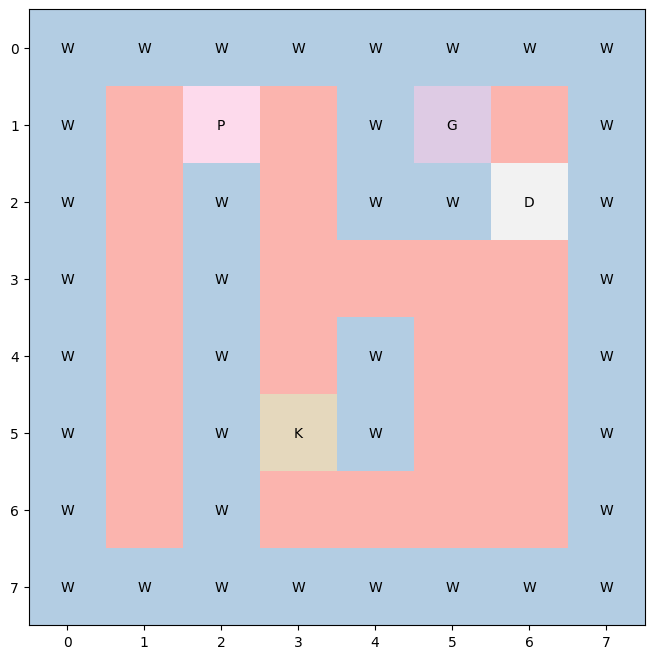

Total Reward: -0.01
Step 2: Action=UP, Player=[1, 2], New Position=[0, 2]


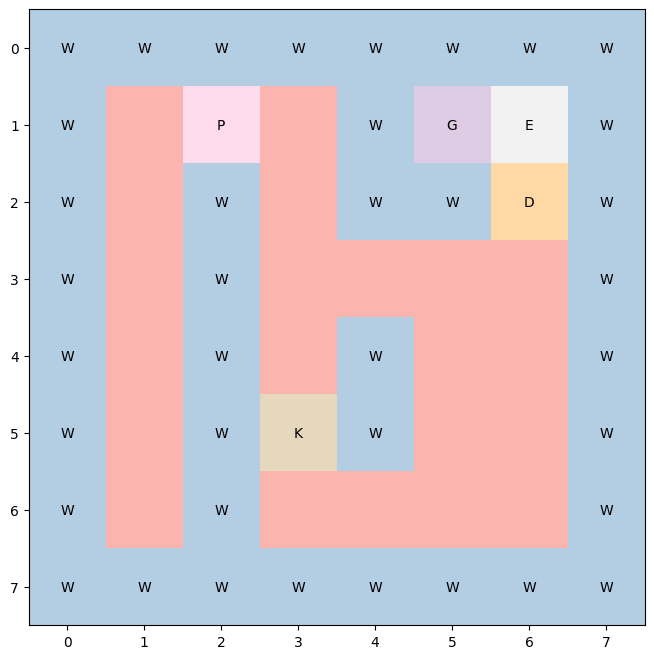

Total Reward: -0.12
Step 3: Action=DOWN, Player=[1, 2], New Position=[2, 2]


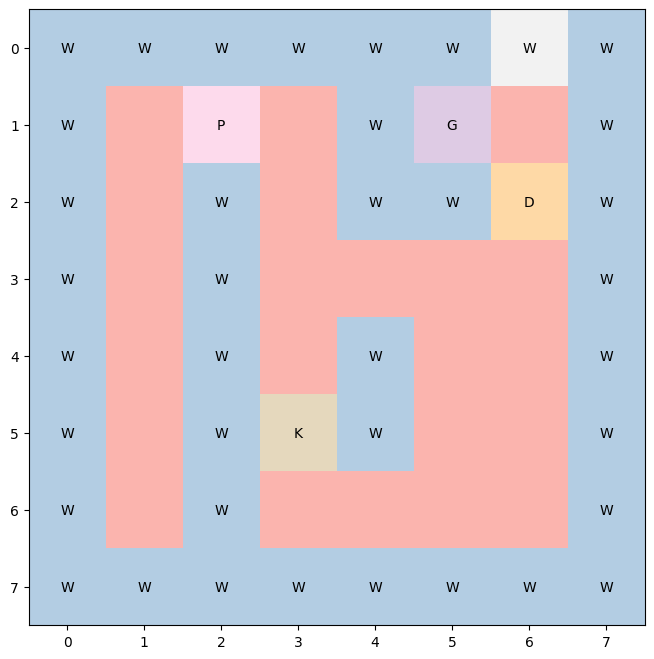

Total Reward: -0.23
Step 4: Action=RIGHT, Player=[1, 2], New Position=[1, 3]


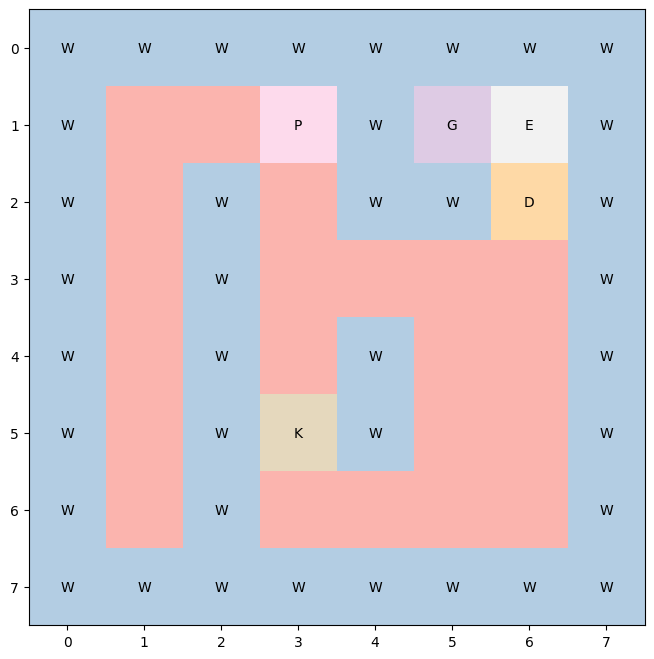

Total Reward: -0.24000000000000002
Step 5: Action=DOWN, Player=[1, 3], New Position=[2, 3]


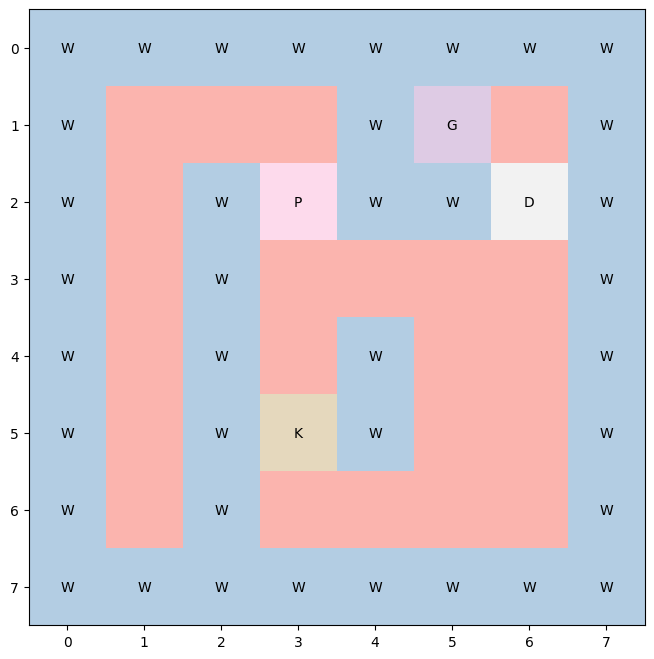

Total Reward: -0.25
Step 6: Action=UP, Player=[2, 3], New Position=[1, 3]


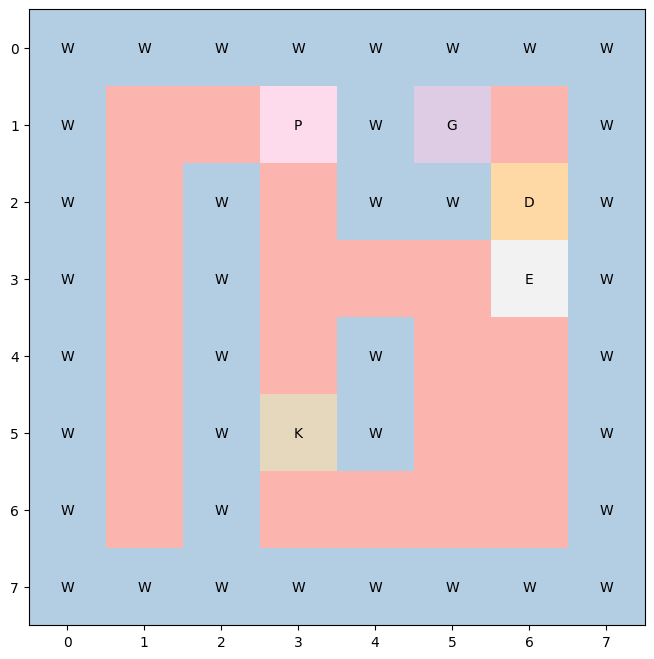

Total Reward: -0.26
Step 7: Action=UP, Player=[1, 3], New Position=[0, 3]


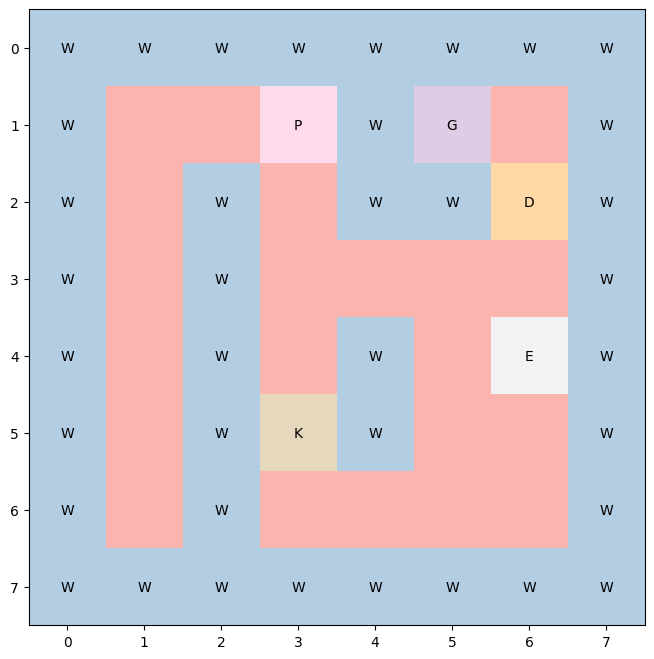

Total Reward: -0.37
Step 8: Action=DOWN, Player=[1, 3], New Position=[2, 3]


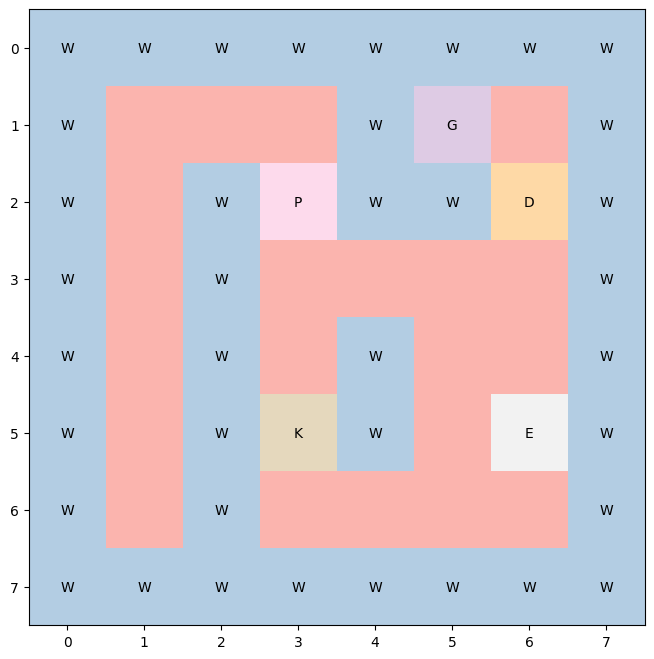

Total Reward: -0.38
Step 9: Action=UP, Player=[2, 3], New Position=[1, 3]


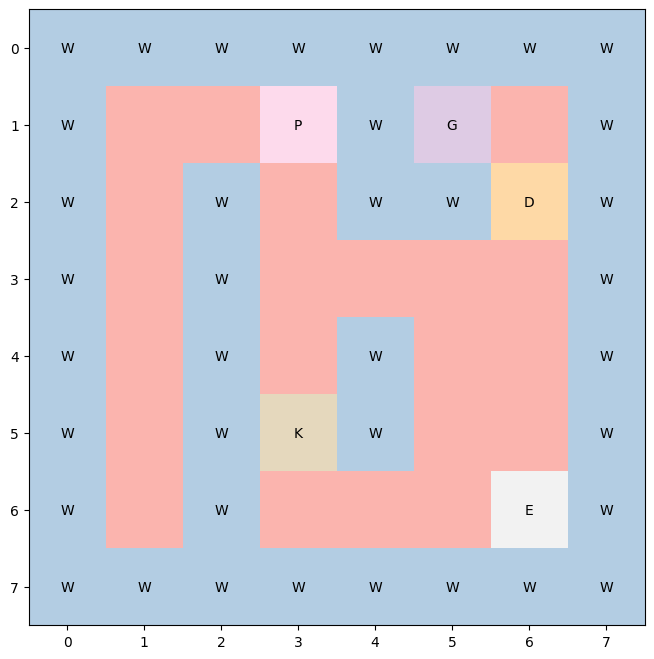

Total Reward: -0.39
Step 10: Action=RIGHT, Player=[1, 3], New Position=[1, 4]


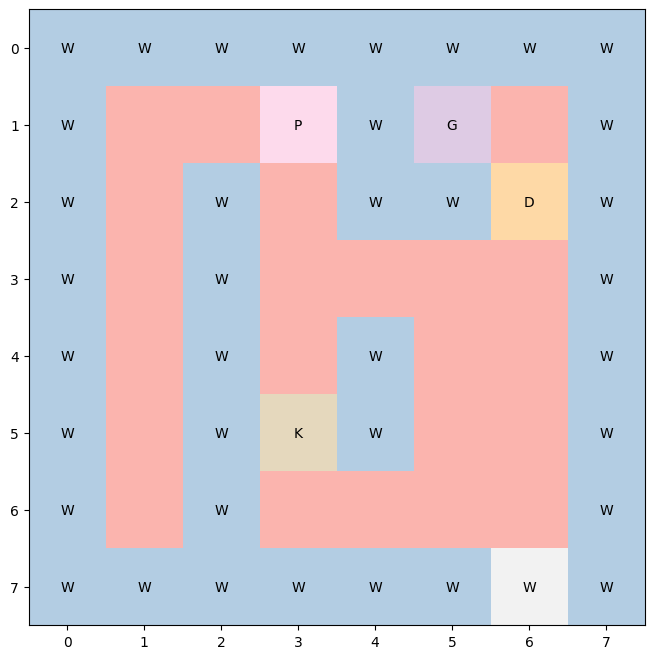

Total Reward: -0.5
Step 11: Action=DOWN, Player=[1, 3], New Position=[2, 3]


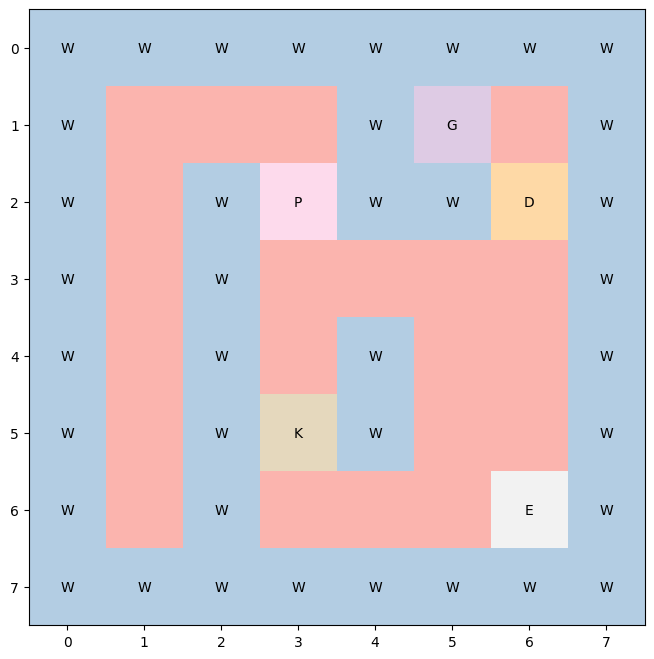

Total Reward: -0.51
Step 12: Action=RIGHT, Player=[2, 3], New Position=[2, 4]


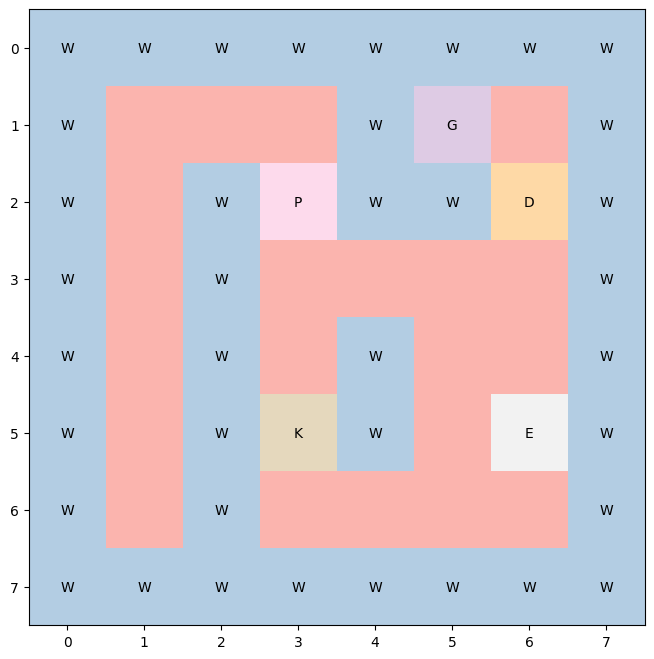

Total Reward: -0.62
Step 13: Action=RIGHT, Player=[2, 3], New Position=[2, 4]


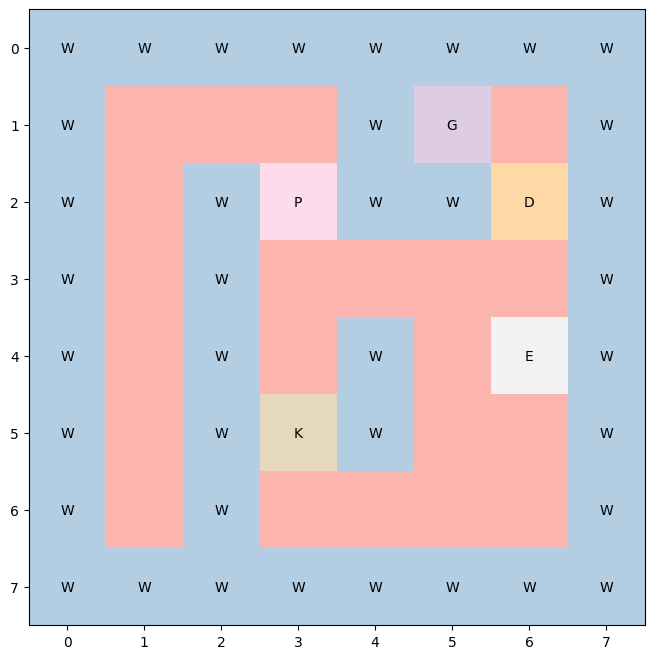

Total Reward: -0.73
Step 14: Action=RIGHT, Player=[2, 3], New Position=[2, 4]


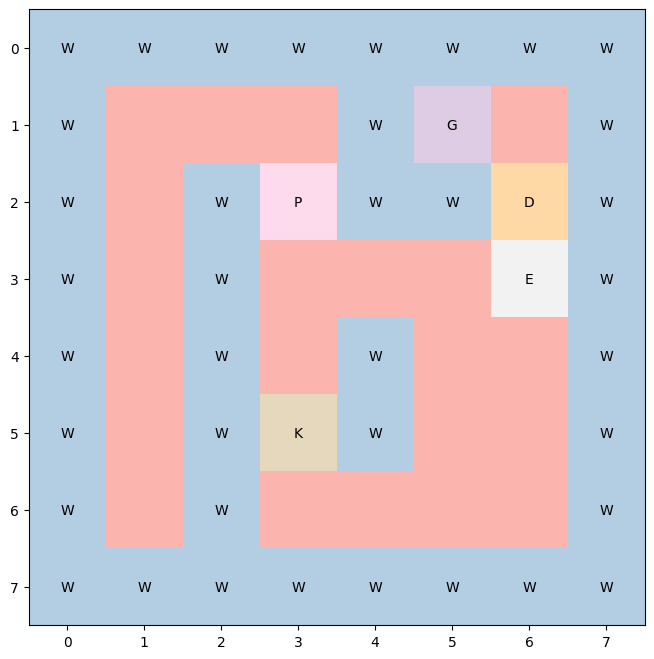

Total Reward: -0.84
Step 15: Action=UP, Player=[2, 3], New Position=[1, 3]


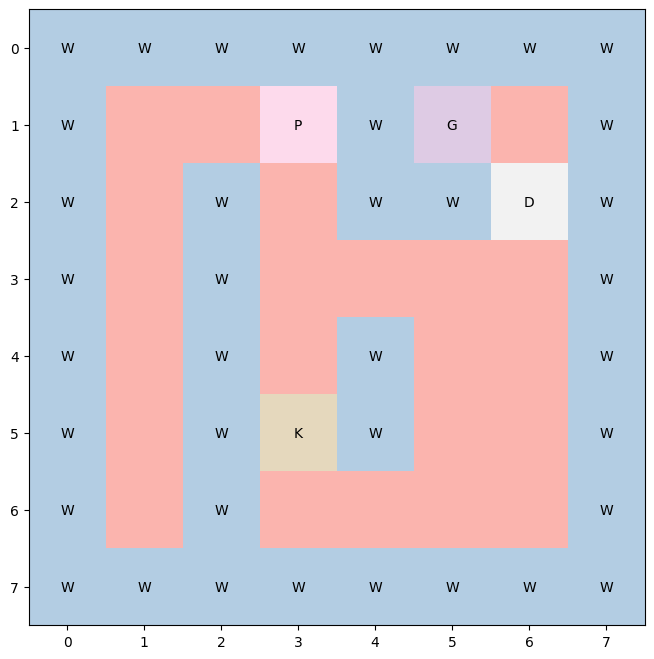

Total Reward: -0.85
Step 16: Action=LEFT, Player=[1, 3], New Position=[1, 2]


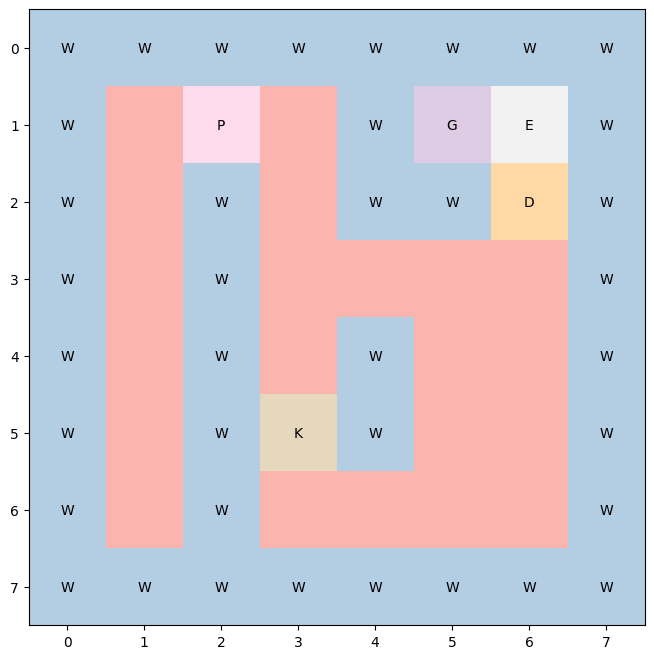

Total Reward: -0.86
Step 17: Action=UP, Player=[1, 2], New Position=[0, 2]


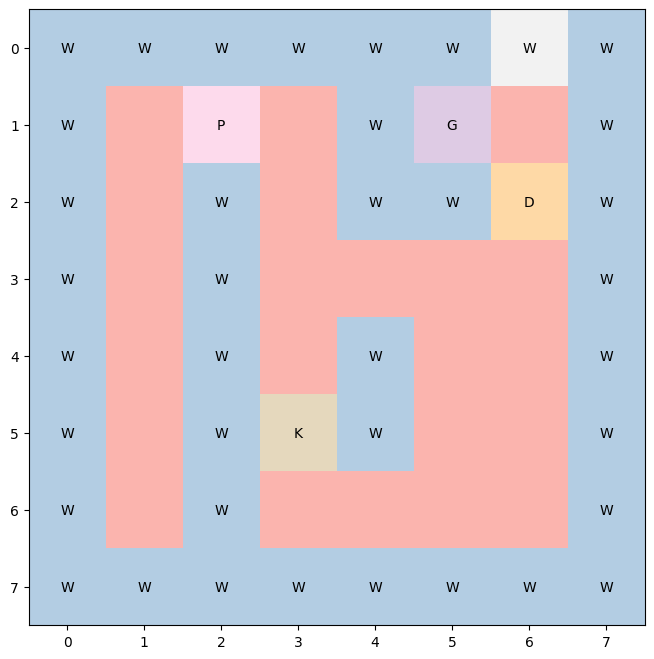

Total Reward: -0.97
Step 18: Action=RIGHT, Player=[1, 2], New Position=[1, 3]


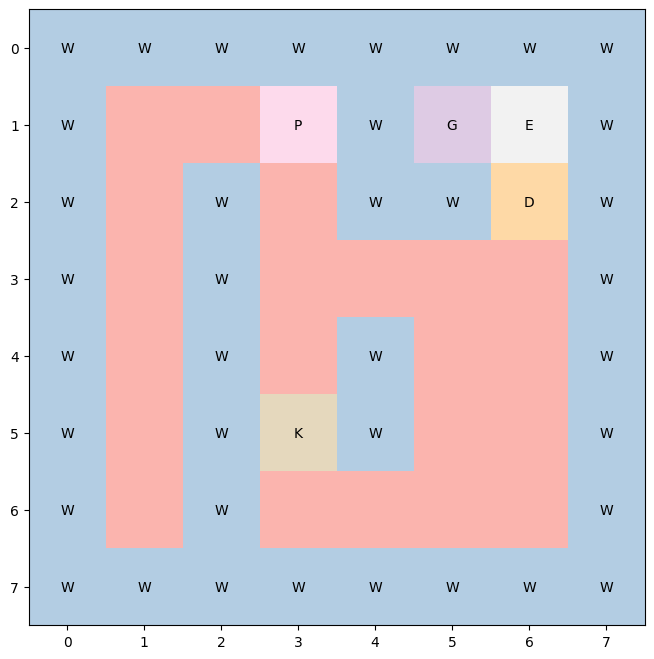

Total Reward: -0.98
Step 19: Action=LEFT, Player=[1, 3], New Position=[1, 2]


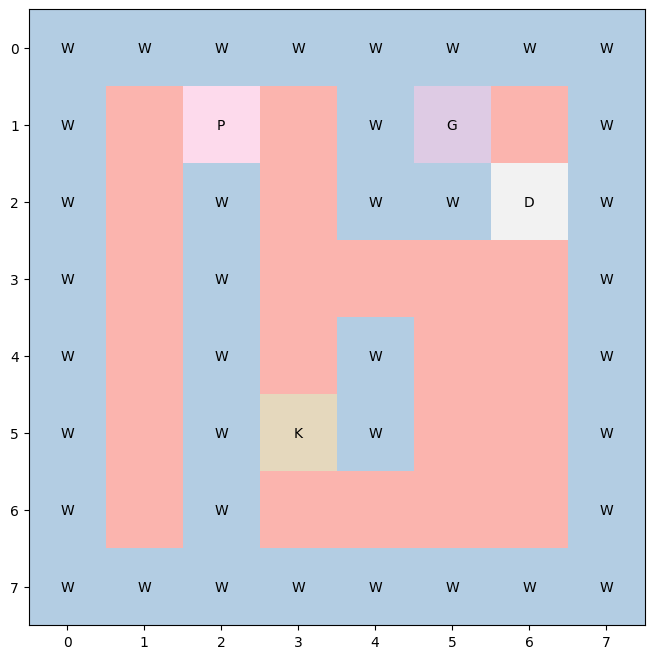

Total Reward: -0.99
Step 20: Action=DOWN, Player=[1, 2], New Position=[2, 2]


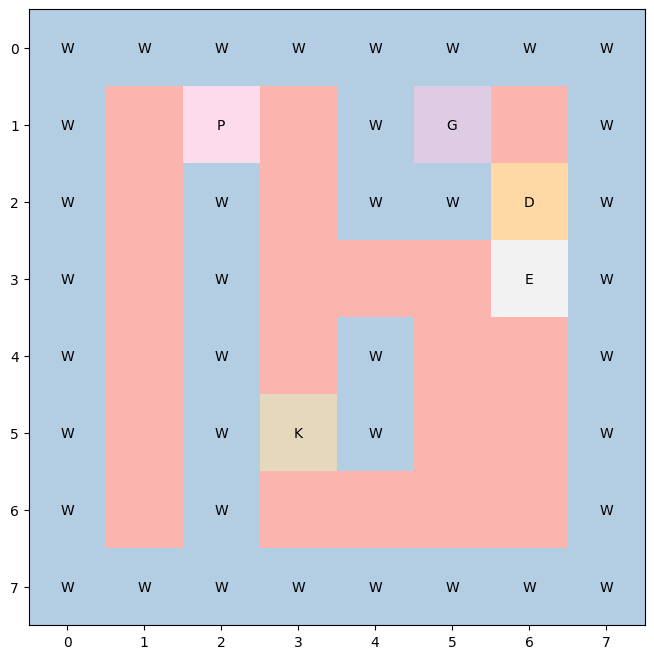

Total Reward: -1.1
Step 21: Action=LEFT, Player=[1, 2], New Position=[1, 1]


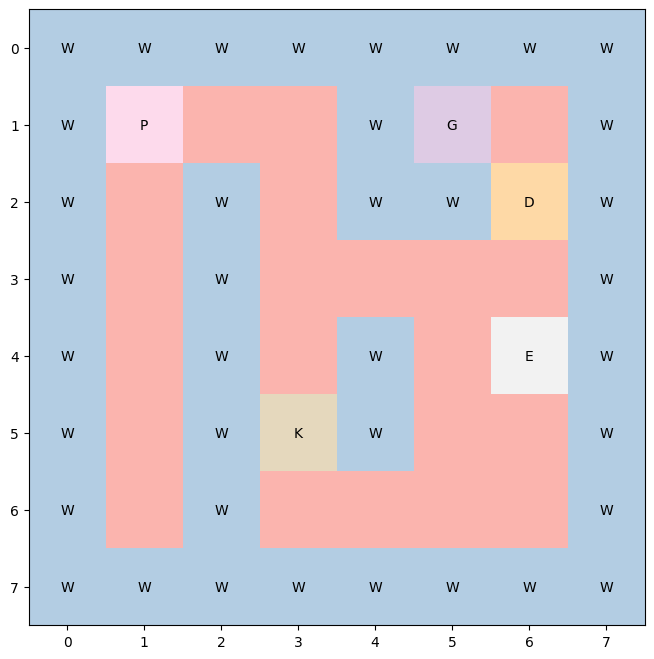

Total Reward: -1.11
Step 22: Action=RIGHT, Player=[1, 1], New Position=[1, 2]


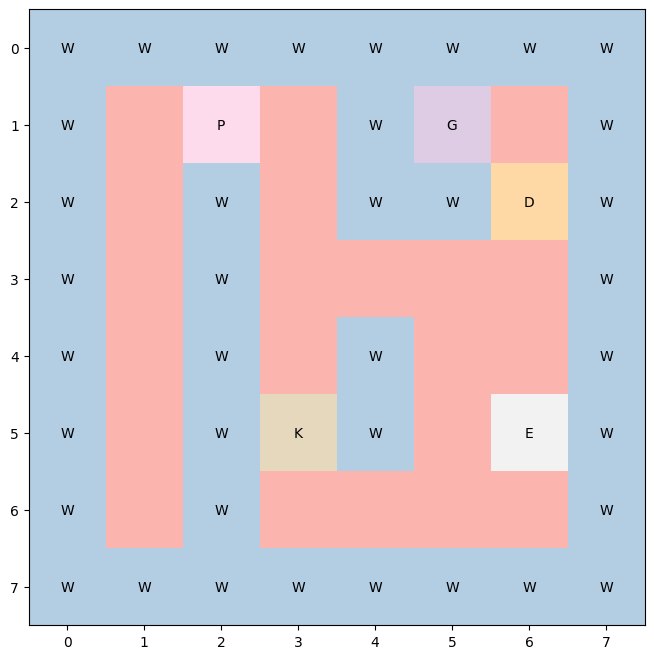

Total Reward: -1.12
Step 23: Action=LEFT, Player=[1, 2], New Position=[1, 1]


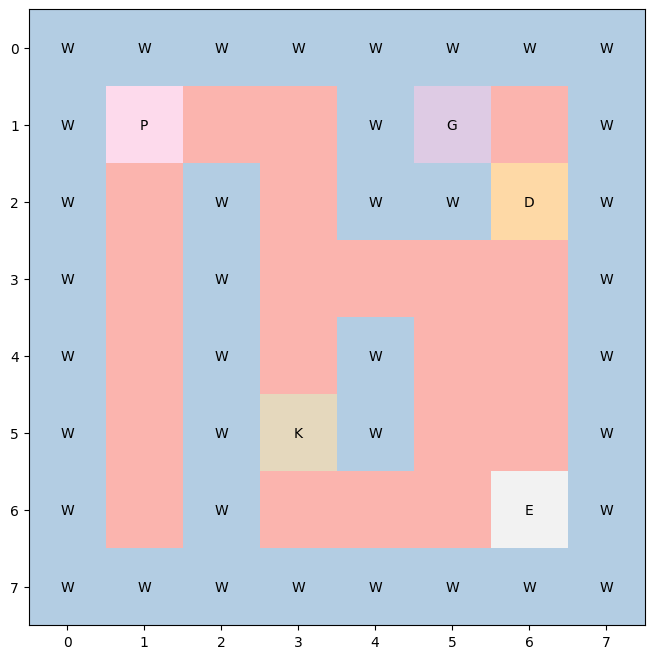

Total Reward: -1.1300000000000001
Step 24: Action=DOWN, Player=[1, 1], New Position=[2, 1]


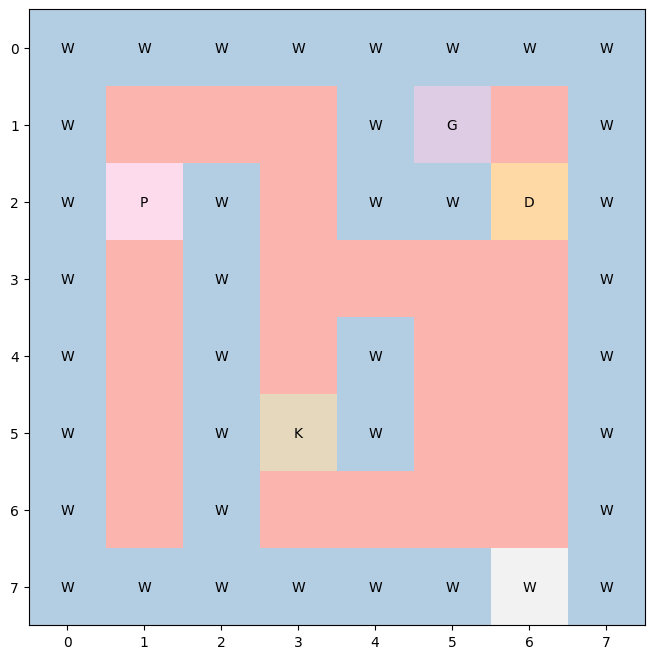

Total Reward: -1.1400000000000001
Step 25: Action=UP, Player=[2, 1], New Position=[1, 1]


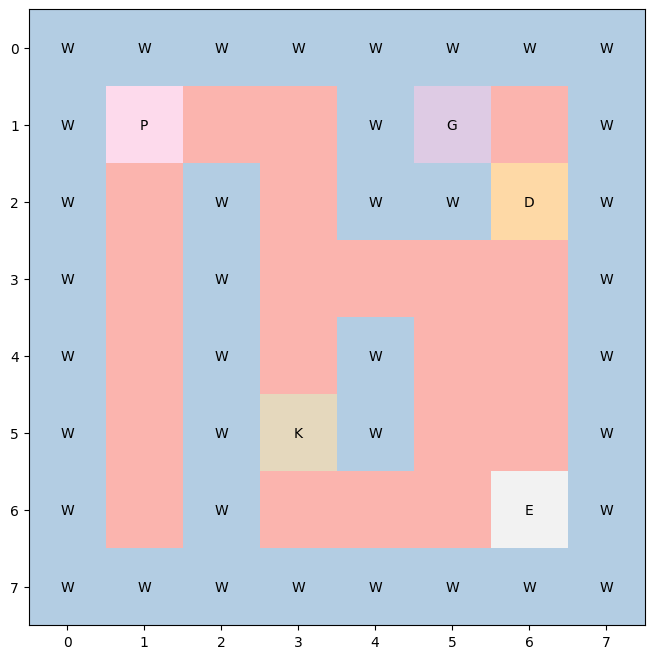

Total Reward: -1.1500000000000001
Step 26: Action=RIGHT, Player=[1, 1], New Position=[1, 2]


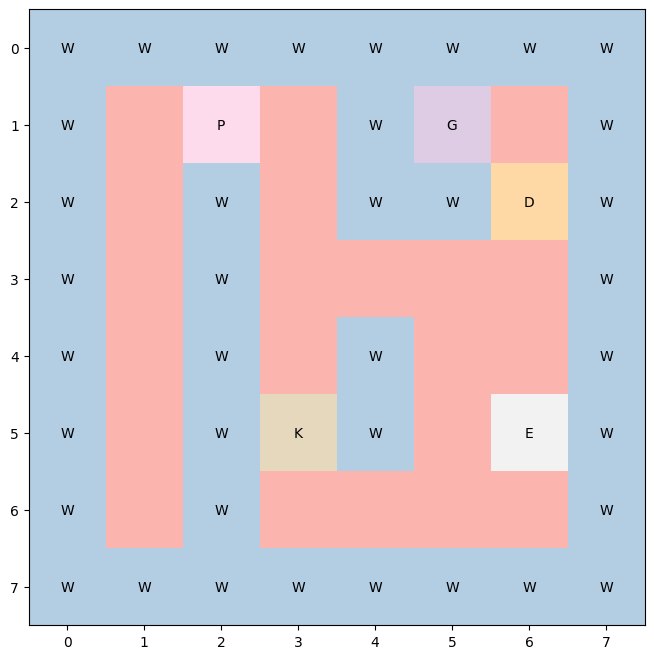

Total Reward: -1.1600000000000001
Step 27: Action=RIGHT, Player=[1, 2], New Position=[1, 3]


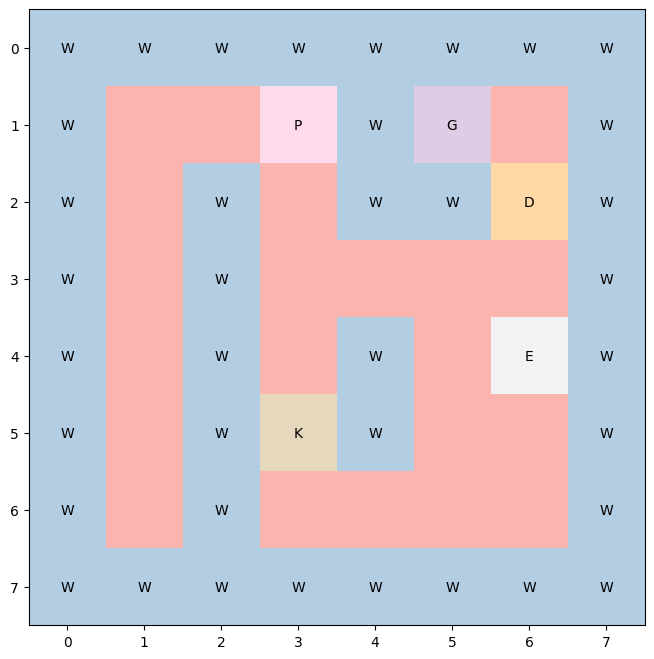

Total Reward: -1.1700000000000002
Step 28: Action=DOWN, Player=[1, 3], New Position=[2, 3]


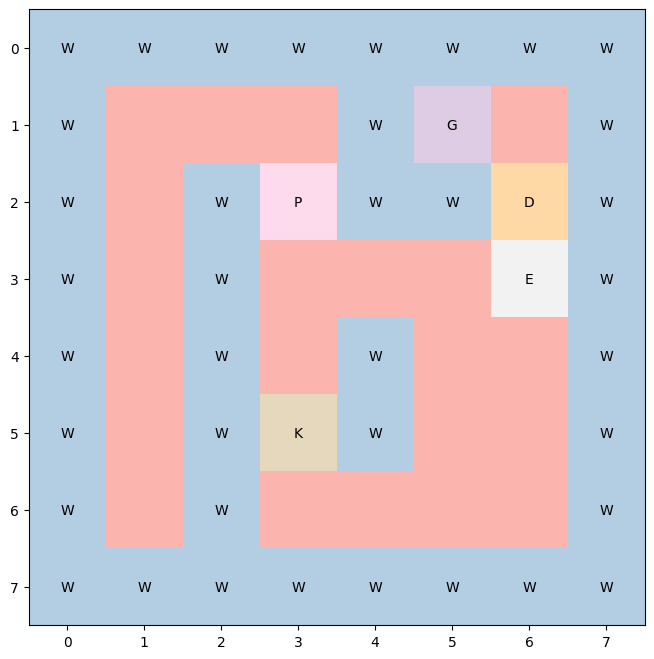

Total Reward: -1.1800000000000002
Step 29: Action=RIGHT, Player=[2, 3], New Position=[2, 4]


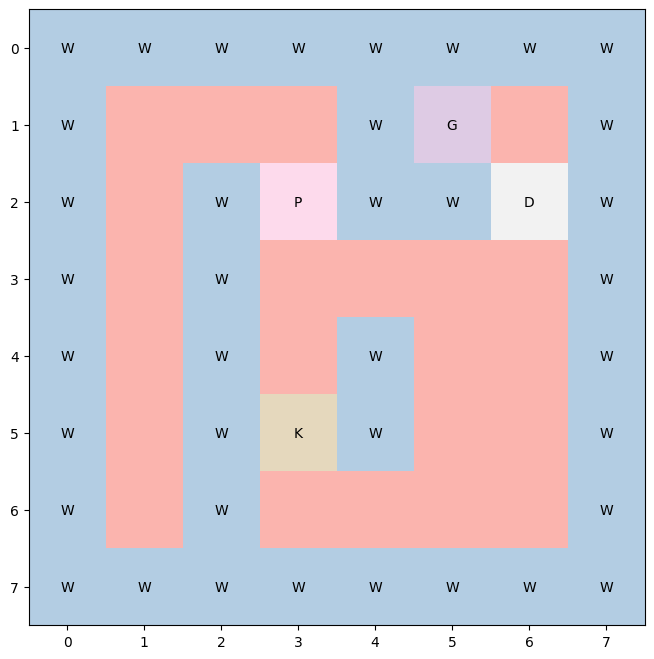

Total Reward: -1.2900000000000003
Step 30: Action=UP, Player=[2, 3], New Position=[1, 3]


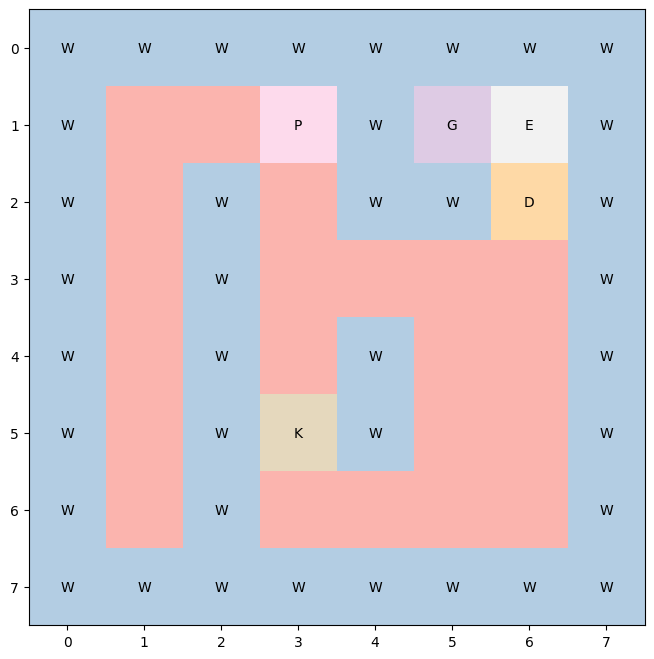

Total Reward: -1.3000000000000003
Step 31: Action=LEFT, Player=[1, 3], New Position=[1, 2]


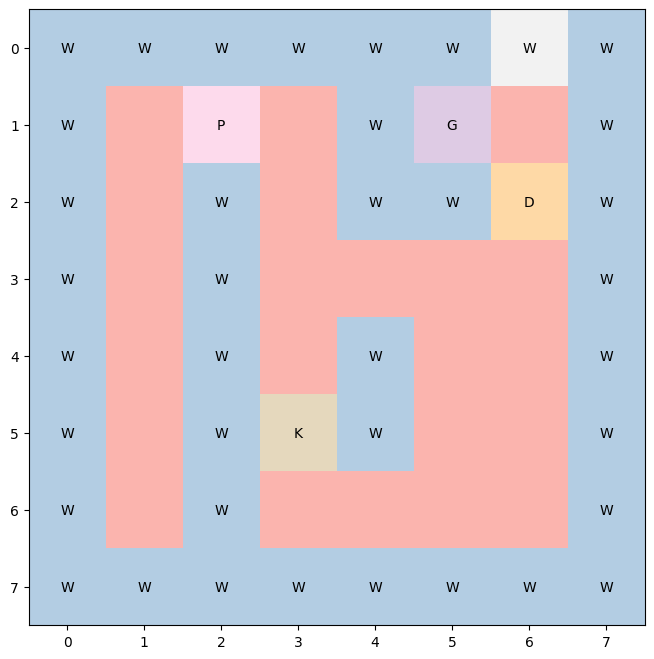

Total Reward: -1.3100000000000003
Step 32: Action=DOWN, Player=[1, 2], New Position=[2, 2]


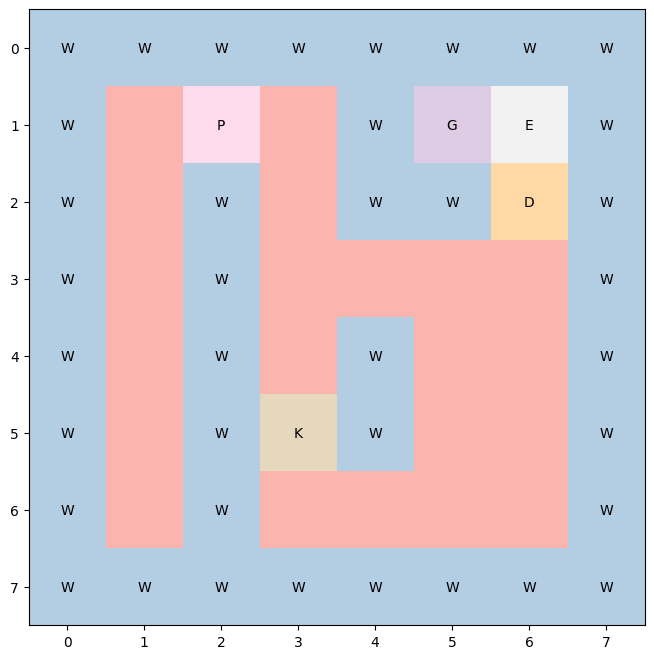

Total Reward: -1.4200000000000004
Step 33: Action=RIGHT, Player=[1, 2], New Position=[1, 3]


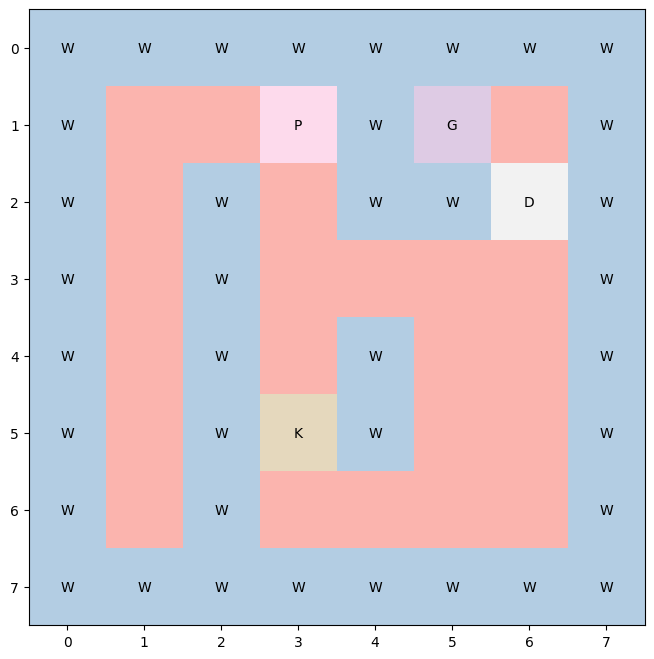

Total Reward: -1.4300000000000004
Step 34: Action=DOWN, Player=[1, 3], New Position=[2, 3]


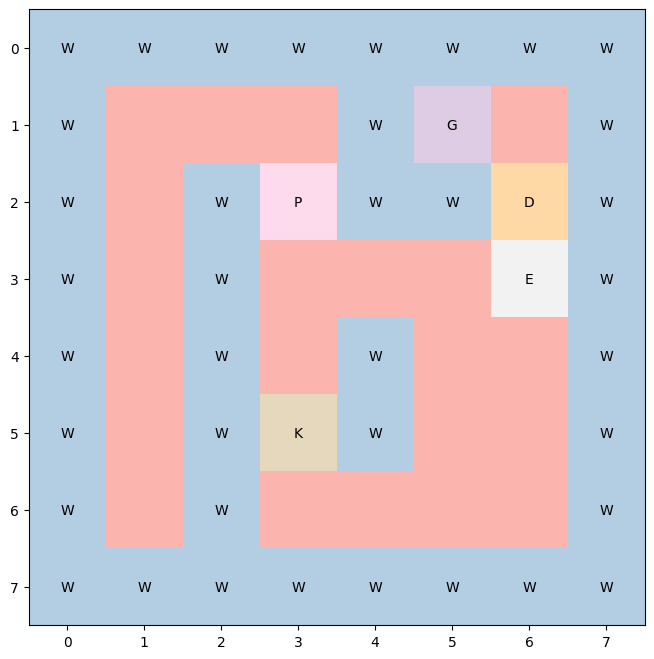

Total Reward: -1.4400000000000004
Step 35: Action=RIGHT, Player=[2, 3], New Position=[2, 4]


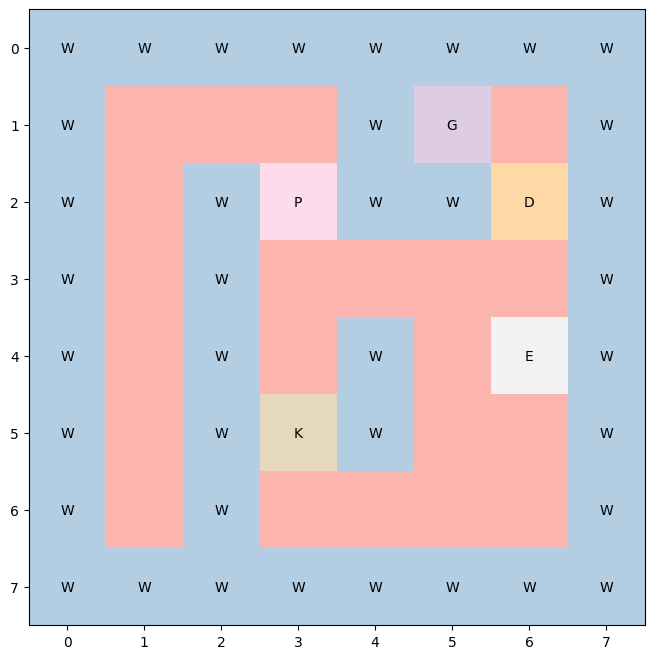

Total Reward: -1.5500000000000005
Step 36: Action=DOWN, Player=[2, 3], New Position=[3, 3]


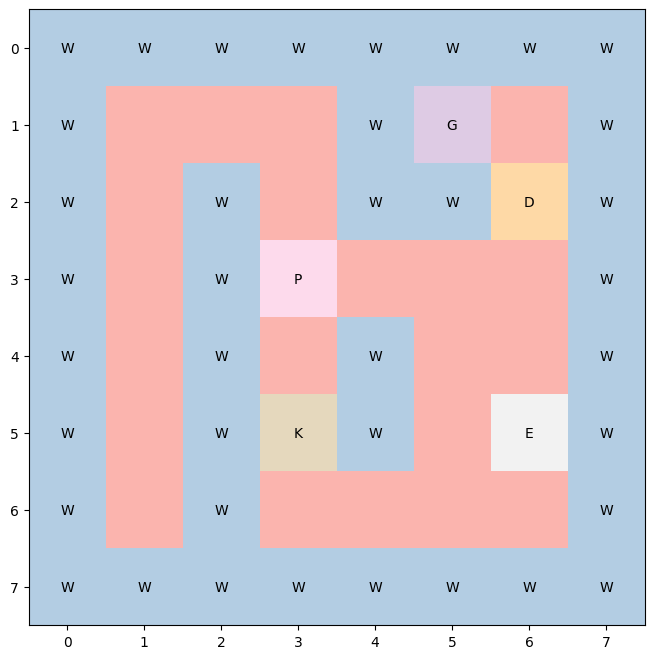

Total Reward: -1.5600000000000005
Step 37: Action=DOWN, Player=[3, 3], New Position=[4, 3]


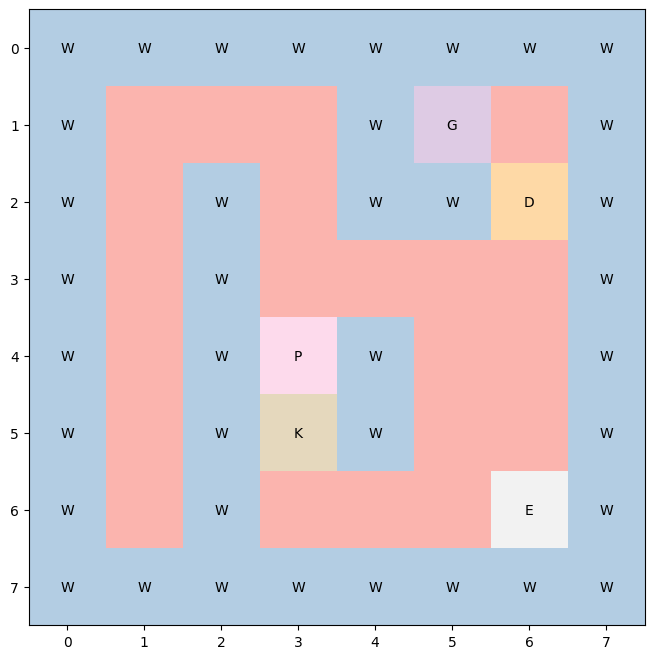

Total Reward: -1.5700000000000005
Step 38: Action=DOWN, Player=[4, 3], New Position=[5, 3]


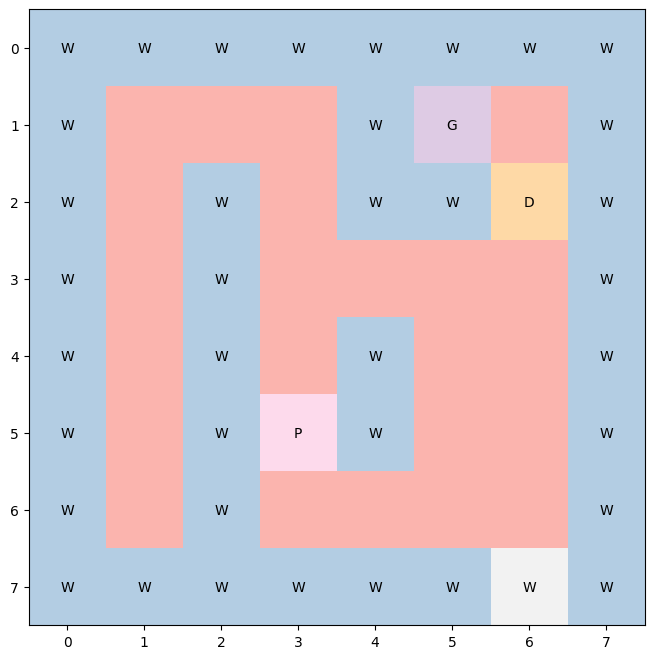

Total Reward: -1.5800000000000005
Step 39: Action=UP, Player=[5, 3], New Position=[4, 3]


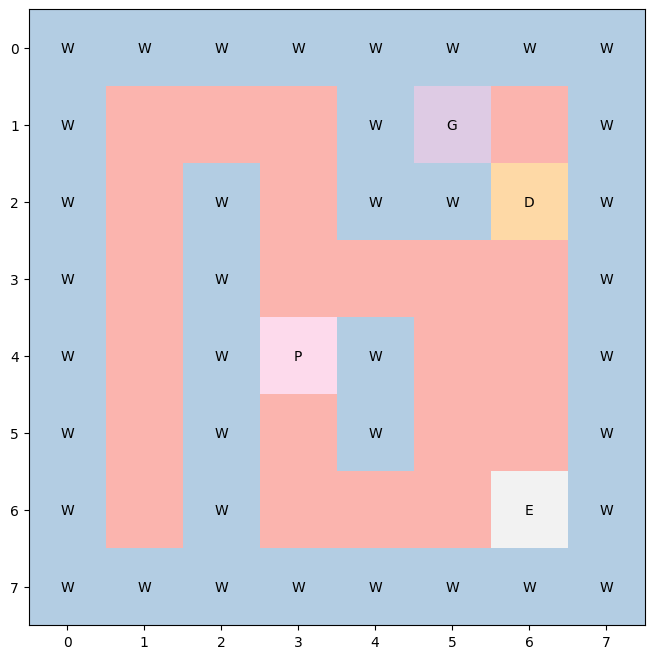

Total Reward: -1.5900000000000005
Step 40: Action=LEFT, Player=[4, 3], New Position=[4, 2]


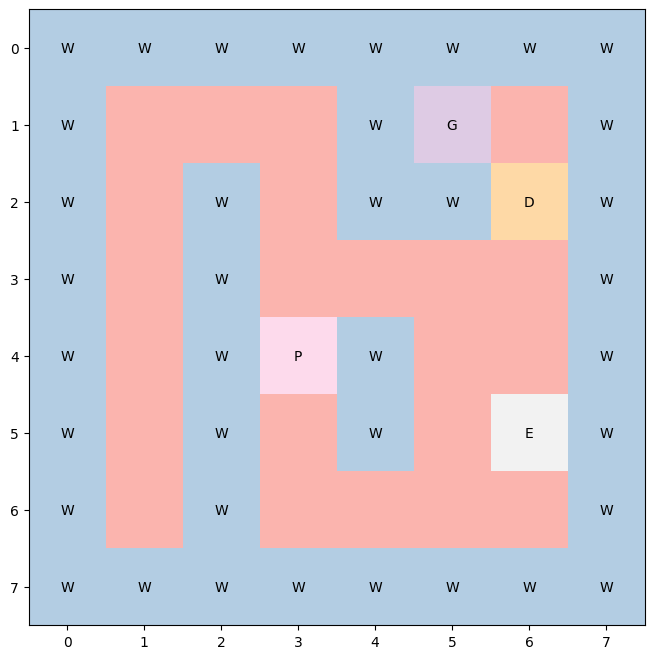

Total Reward: -1.7000000000000006
Step 41: Action=LEFT, Player=[4, 3], New Position=[4, 2]


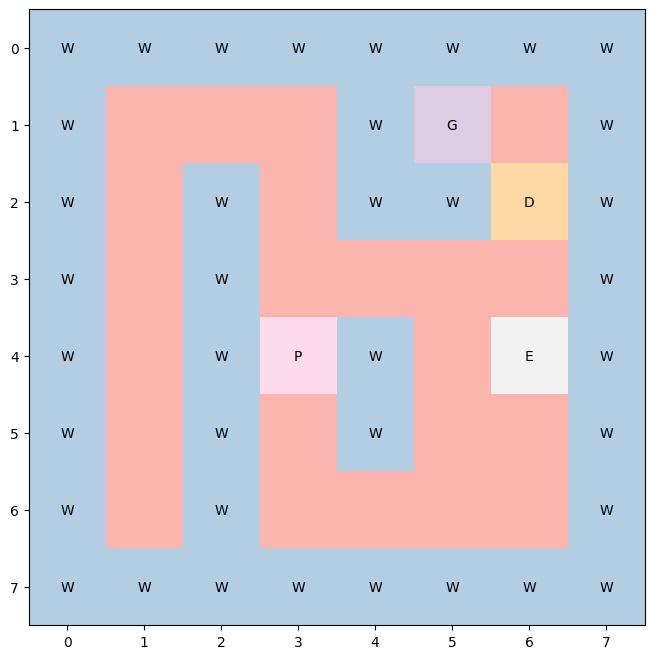

Total Reward: -1.8100000000000007
Step 42: Action=LEFT, Player=[4, 3], New Position=[4, 2]


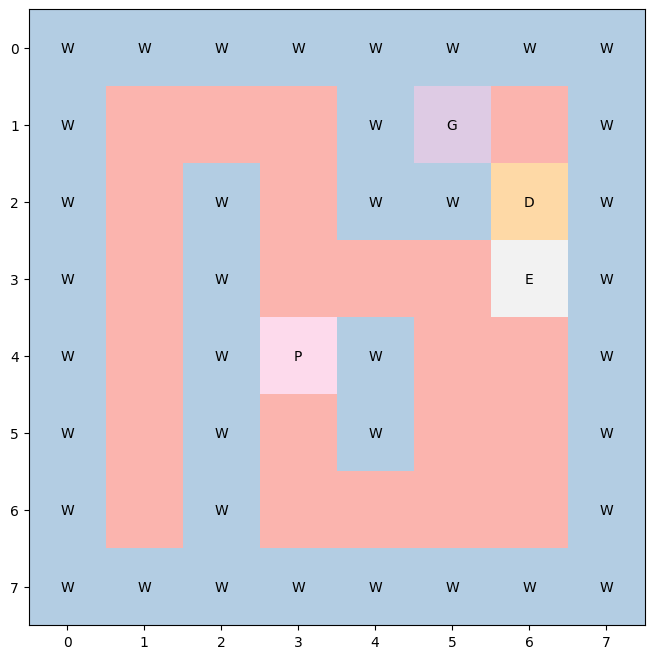

Total Reward: -1.9200000000000008
Step 43: Action=DOWN, Player=[4, 3], New Position=[5, 3]


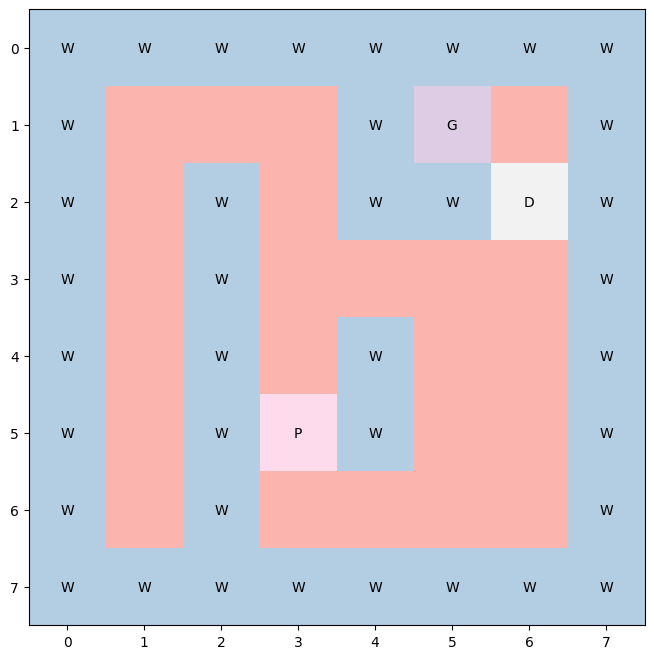

Total Reward: -1.9300000000000008
Step 44: Action=RIGHT, Player=[5, 3], New Position=[5, 4]


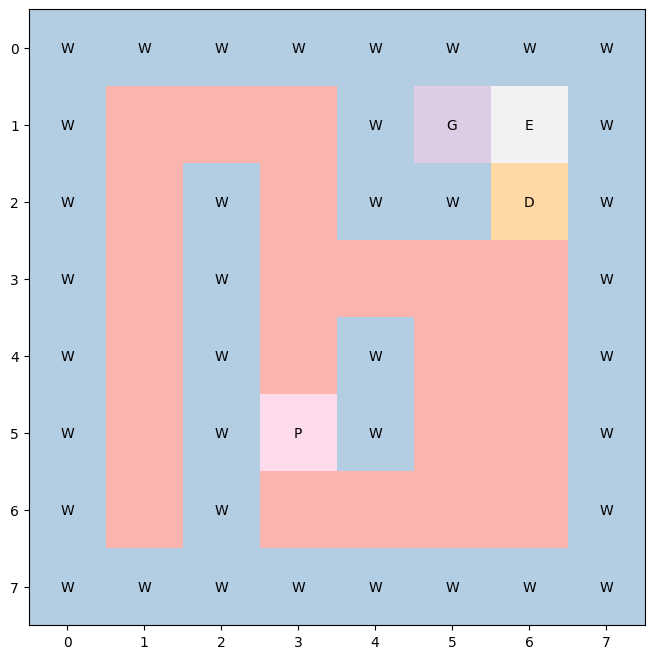

Total Reward: -2.0400000000000005
Step 45: Action=RIGHT, Player=[5, 3], New Position=[5, 4]


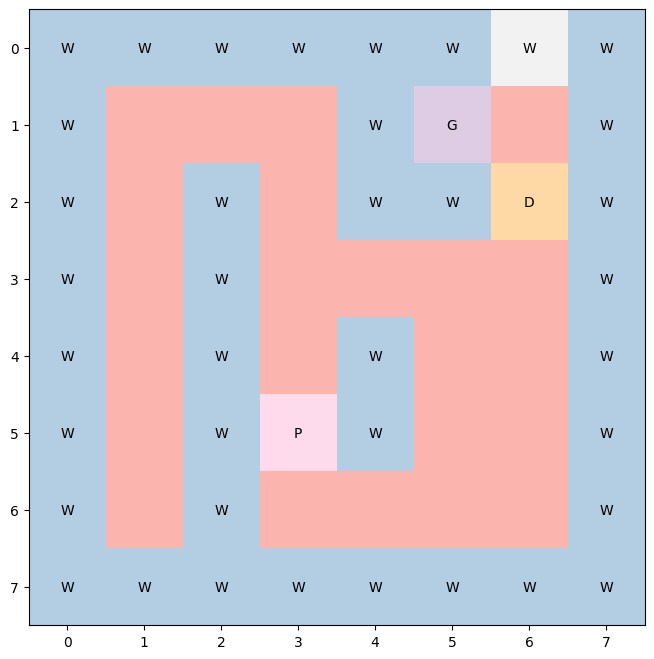

Total Reward: -2.1500000000000004
Step 46: Action=RIGHT, Player=[5, 3], New Position=[5, 4]


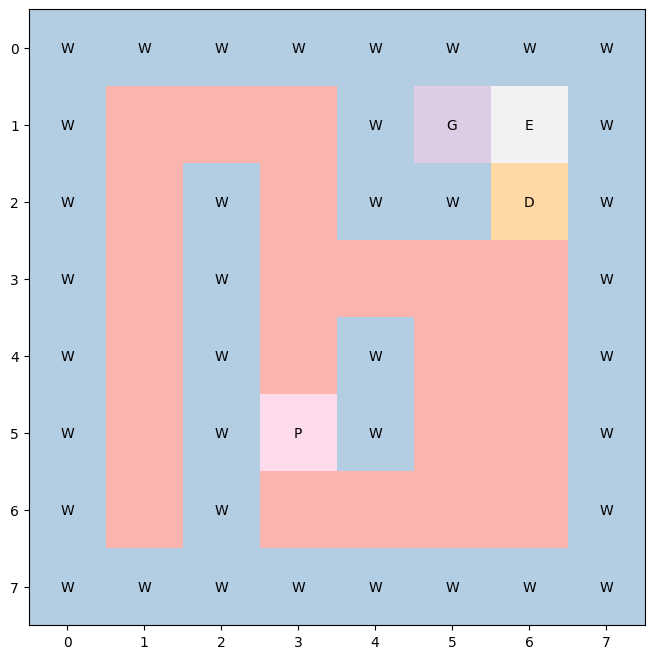

Total Reward: -2.2600000000000002
Step 47: Action=DOWN, Player=[5, 3], New Position=[6, 3]


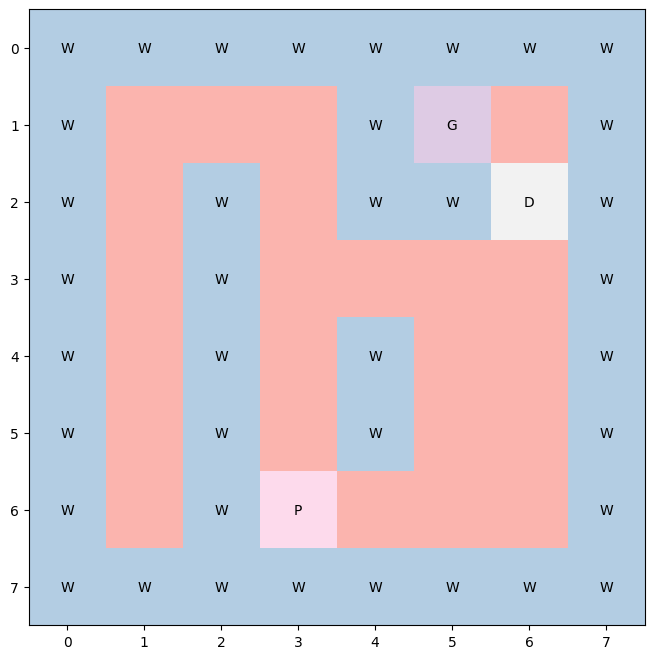

Total Reward: -2.27
Step 48: Action=LEFT, Player=[6, 3], New Position=[6, 2]


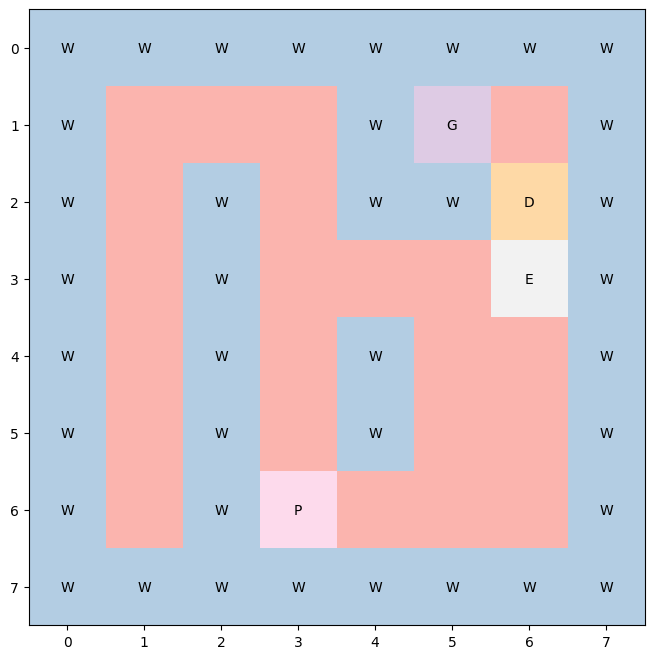

Total Reward: -2.38
Step 49: Action=LEFT, Player=[6, 3], New Position=[6, 2]


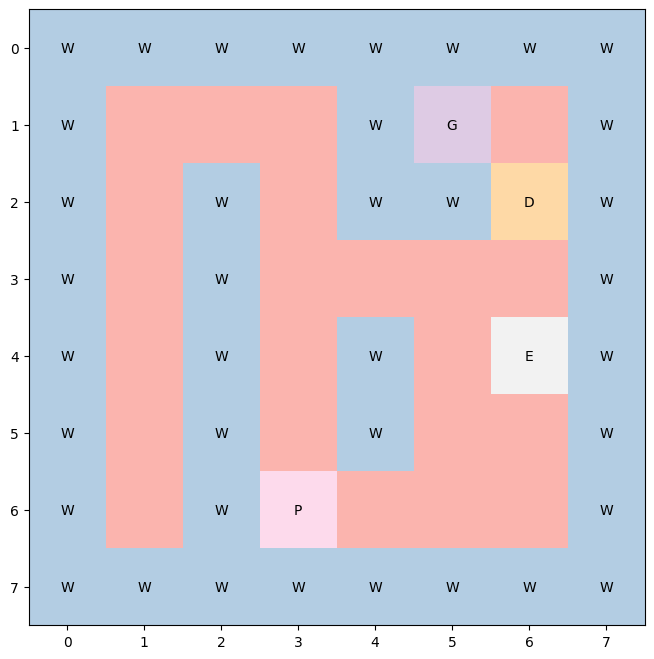

Total Reward: -2.4899999999999998
Step 50: Action=LEFT, Player=[6, 3], New Position=[6, 2]


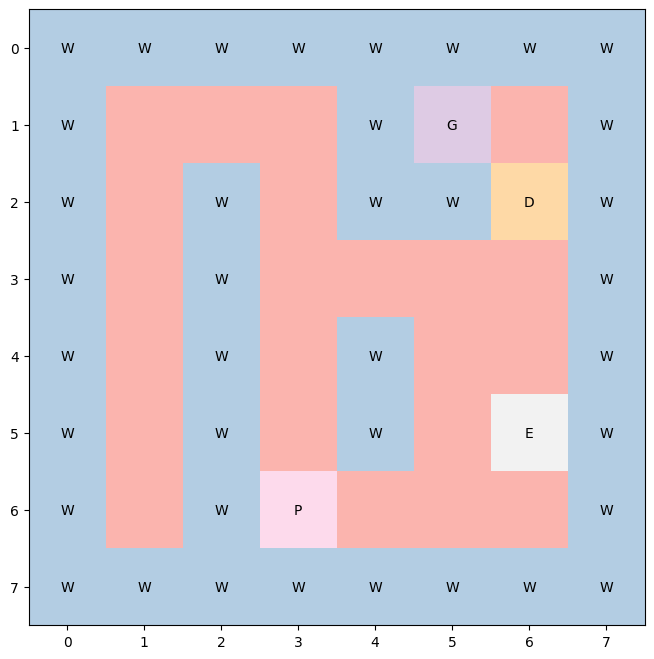

Total Reward: -2.5999999999999996
Simulation ended.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import time


# Define the maze layout
maze = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1, 2, 0, 1],
    [1, 0, 1, 0, 1, 1, 3, 1],
    [1, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 1],
    [1, 0, 1, 4, 1, 0, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1]
]

TILE_SIZE = 64
tiles = ['empty', 'wall', 'goal', 'door', 'key']
player_pos = [1, 1] 
enemy_pos = [3, 6]  
enemy_yv = -1
unlock = 0


actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']

def get_tile(pos):
    row, col = pos
    return tiles[maze[row][col]]

def move_player(action, pos):
    row, col = pos
    if action == 'UP':
        row -= 1
    elif action == 'DOWN':
        row += 1
    elif action == 'LEFT':
        col -= 1
    elif action == 'RIGHT':
        col += 1
    return [row, col]

def visualize_maze(player_pos, enemy_pos):
    visual_maze = np.array(maze)
    visual_maze[player_pos[0], player_pos[1]] = 5  
    visual_maze[enemy_pos[0], enemy_pos[1]] = 6 

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(visual_maze, cmap='Pastel1', interpolation='nearest')


    for i in range(len(maze)):
        for j in range(len(maze[0])):
            if maze[i][j] == 1:  # Wall
                ax.text(j, i, 'W', ha='center', va='center', color='black')
            elif maze[i][j] == 2:  # Goal
                ax.text(j, i, 'G', ha='center', va='center', color='black')
            elif maze[i][j] == 3:  # Door
                ax.text(j, i, 'D', ha='center', va='center', color='black')
            elif maze[i][j] == 4:  # Key
                ax.text(j, i, 'K', ha='center', va='center', color='black')
            elif visual_maze[i, j] == 5:  # Player
                ax.text(j, i, 'P', ha='center', va='center', color='black')
            elif visual_maze[i, j] == 6:  # Enemy
                ax.text(j, i, 'E', ha='center', va='center', color='black')

    plt.show()




def simulate(steps=50):
    global player_pos, enemy_pos, unlock, enemy_yv
    total_reward = 0
    rewards = [] 

    for step in range(steps):
        # Random action for player
        action = random.choice(actions)
        new_pos = move_player(action, player_pos)
        tile = get_tile(new_pos)

        # Print out the action and position change
        print(f"Step {step + 1}: Action={action}, Player={player_pos}, New Position={new_pos}")

        # Check movement and rewards
        if tile == 'empty':
            player_pos = new_pos
        elif tile == 'goal':
            print("Goal Reached!")
            total_reward += 1
            break
        elif tile == 'key':
            unlock += 1
            maze[new_pos[0]][new_pos[1]] = 0  # Collect the key
            player_pos = new_pos
        elif tile == 'door' and unlock > 0:
            unlock -= 1
            maze[new_pos[0]][new_pos[1]] = 0  # Open the door
            player_pos = new_pos
        elif tile == 'wall':
            total_reward -= 0.1  # Small penalty for hitting the wall

        # Move enemy
        enemy_pos[0] += enemy_yv
        if get_tile(enemy_pos) == 'wall':
            enemy_yv *= -1
        if player_pos == enemy_pos:
            print("Caught by Enemy!")
            total_reward -= 1
            break

        # Reward for steps
        total_reward -= 0.01  # Small penalty for each step
        rewards.append(total_reward)

        # Visualize the maze and player's actions
        visualize_maze(player_pos, enemy_pos)
        time.sleep(0.5)  # Add delay for better viewing

        # Debug info
        print(f"Total Reward: {total_reward}")

    print("Simulation ended.")
    return total_reward, rewards

# Run simulation
reward, rewards = simulate()

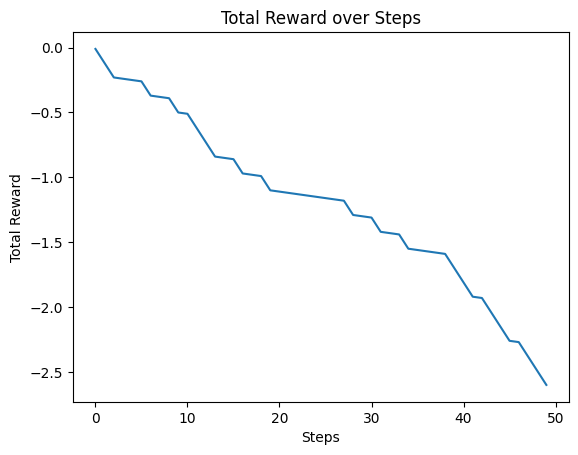

In [5]:
# Plot the reward over time
plt.plot(rewards)
plt.xlabel('Steps')
plt.ylabel('Total Reward')
plt.title('Total Reward over Steps')
plt.show()


###Task 3
For self implementation:

Add value function if player is closer to goal reward positive is far then negative. based on manhattan distance.

In [ ]:
import random

maze = [
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1, 2, 0, 1],    #  0= Open Space, 1= Wall, 2= Goal, 3 = Door, 4= Key
    [1, 0, 1, 0, 1, 1, 3, 1],
    [1, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 1],
    [1, 0, 1, 4, 1, 0, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1]
]

TILE_SIZE = 64
tiles = ['empty', 'wall', 'goal', 'door', 'key']
player_pos = [1, 1] 
enemy_pos = [3, 6]  
enemy_yv = -1
unlock = 0


actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']

def simulate(steps=50):
    global player_pos, enemy_pos, unlock, enemy_yv
    total_reward = 0


    goal_pos = None
    for i in range(len(maze)):
        for j in range(len(maze[0])):
            if maze[i][j] == 2:  
                goal_pos = (i, j)
                break
        if goal_pos:
            break

    if not goal_pos:
        print("No goal found in the maze!")
        return total_reward

    for step in range(steps):

        action = random.choice(actions)
        new_pos = move_player(action, player_pos)


        if not (0 <= new_pos[0] < len(maze) and 0 <= new_pos[1] < len(maze[0])):
            total_reward -= 0.05  
            continue

        tile = get_tile(new_pos)


        current_dist = abs(player_pos[0] - goal_pos[0]) + abs(player_pos[1] - goal_pos[1])
        new_dist = abs(new_pos[0] - goal_pos[0]) + abs(new_pos[1] - goal_pos[1])


        if tile == 'empty' or tile == 'key' or tile == 'goal' or (tile == 'door' and unlock > 0):
            if tile == 'goal':
                print("Goal Reached!")
                total_reward += 10  
                break
            elif tile == 'key':
                unlock += 1
                maze[new_pos[0]][new_pos[1]] = 0  
            elif tile == 'door' and unlock > 0:
                unlock -= 1
                maze[new_pos[0]][new_pos[1]] = 0  

            player_pos = new_pos

            if new_dist < current_dist:
                total_reward += 1
            elif new_dist > current_dist:
                total_reward -= 0.5
        elif tile == 'wall':
            total_reward -= 0.05 


        enemy_pos[0] += enemy_yv
        if get_tile(enemy_pos) == 'wall':
            enemy_yv *= -1
        if player_pos == enemy_pos:
            print("Caught by Enemy!")
            total_reward -= 1
            break
        total_reward -= 0.001  

        print(f"Step {step + 1}: Action={action}, Player={player_pos}, Reward={total_reward}")

    print("Simulation ended.")
    return total_reward

reward = simulate()
print(f"Total Reward: {reward}")


Step 1: Action=DOWN, Player=[2, 1], Reward=-0.501
Step 2: Action=DOWN, Player=[3, 1], Reward=-1.0019999999999998
Step 3: Action=LEFT, Player=[3, 1], Reward=-1.0529999999999997
Step 4: Action=LEFT, Player=[3, 1], Reward=-1.1039999999999996
Step 5: Action=DOWN, Player=[4, 1], Reward=-1.6049999999999995
Step 6: Action=LEFT, Player=[4, 1], Reward=-1.6559999999999995
Step 7: Action=RIGHT, Player=[4, 1], Reward=-1.7069999999999994
Step 8: Action=DOWN, Player=[5, 1], Reward=-2.2079999999999993
Step 9: Action=LEFT, Player=[5, 1], Reward=-2.258999999999999
Step 10: Action=DOWN, Player=[6, 1], Reward=-2.759999999999999
Step 11: Action=RIGHT, Player=[6, 1], Reward=-2.8109999999999986
Step 12: Action=RIGHT, Player=[6, 1], Reward=-2.8619999999999983
Step 13: Action=UP, Player=[5, 1], Reward=-1.8629999999999982
Step 14: Action=DOWN, Player=[6, 1], Reward=-2.363999999999998
Step 15: Action=LEFT, Player=[6, 1], Reward=-2.414999999999998
Step 16: Action=UP, Player=[5, 1], Reward=-1.4159999999999977
Ste